In [18]:
import pandas as pd

# Read the path
# Please change the path according to the datafile attached to this notebook project!
path = r"E:\Courses\Datasets\corporateCreditRatingWithFinancialRatios.csv"

df = pd.read_csv(
    path,
    encoding='utf-8',
    low_memory=False
)

# Check the errors when reading the file
df.head()
df.tail()
df.shape
df.columns

Index(['Rating Agency', 'Corporation', 'Rating', 'Rating Date', 'CIK',
       'Binary Rating', 'SIC Code', 'Sector', 'Ticker', 'Current Ratio',
       'Long-term Debt / Capital', 'Debt/Equity Ratio', 'Gross Margin',
       'Operating Margin', 'EBIT Margin', 'EBITDA Margin',
       'Pre-Tax Profit Margin', 'Net Profit Margin', 'Asset Turnover',
       'ROE - Return On Equity', 'Return On Tangible Equity',
       'ROA - Return On Assets', 'ROI - Return On Investment',
       'Operating Cash Flow Per Share', 'Free Cash Flow Per Share'],
      dtype='object')

In [19]:
# Check the file's information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   object 
 1   Corporation                    7805 non-null   object 
 2   Rating                         7805 non-null   object 
 3   Rating Date                    7805 non-null   object 
 4   CIK                            7805 non-null   int64  
 5   Binary Rating                  7805 non-null   int64  
 6   SIC Code                       7805 non-null   int64  
 7   Sector                         7805 non-null   object 
 8   Ticker                         7805 non-null   object 
 9   Current Ratio                  7805 non-null   float64
 10  Long-term Debt / Capital       7805 non-null   float64
 11  Debt/Equity Ratio              7805 non-null   float64
 12  Gross Margin                   7805 non-null   f

In [20]:
# Flag the NA value
na_values = ["NA", "N/A", "null", "-", "", -99, -999]

# Deal with the dataframe briefly
df = pd.read_csv(
    path,
    encoding='utf-8',
    low_memory=False,
    na_values=na_values
)

df = df.rename(columns={
    'Rating Agency': 'rating_agency',
    'Corporation': 'corporation',
    'Rating': 'rating',
    'Rating Date': 'rating_date',
    'CIK': 'cik',
    'Binary Rating': 'binary_rating',
    'SIC Code': 'sic_code',
    'Sector': 'sector',
    'Ticker': 'ticker',
    'Current Ratio': 'current_ratio',
    'Long-term Debt / Capital': 'lt_debt_capital',
    'Debt/Equity Ratio': 'debt_equity',
    'Gross Margin': 'gross_margin',
    'Operating Margin': 'operating_margin',
    'EBIT Margin': 'ebit_margin',
    'EBITDA Margin': 'ebitda_margin',
    'Pre-Tax Profit Margin': 'pretax_margin',
    'Net Profit Margin': 'net_margin',
    'Asset Turnover': 'asset_turnover',
    'ROE - Return On Equity': 'roe',
    'Return On Tangible Equity': 'rote',
    'ROA - Return On Assets': 'roa',
    'ROI - Return On Investment': 'roi',
    'Operating Cash Flow Per Share': 'ocf_per_share',
    'Free Cash Flow Per Share': 'fcf_per_share'
})

# Handle the date column
df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce')
df['year'] = df['rating_date'].dt.year

#Check the repeated dates
df[['ticker', 'year']].duplicated().sum()

dup_rows = df[df.duplicated(subset=['ticker', 'year'], keep=False)]
dup_rows.sort_values(['ticker', 'year']).head(10)


,rating_agency,corporation,rating,rating_date,cik,binary_rating,sic_code,sector,ticker,current_ratio,...,pretax_margin,net_margin,asset_turnover,roe,rote,roa,roi,ocf_per_share,fcf_per_share,year
1451,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2013-05-29,1158449,1,5531,Shops,AAP,1.2440,...,10.0576,6.2337,1.3449,32.0205,35.0687,8.4024,21.3574,-1.5016,-1.6121,2013
1452,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2013-09-25,1158449,1,5531,Shops,AAP,1.2440,...,10.0576,6.2337,1.3449,32.0205,35.0687,8.4024,21.3574,-1.5016,-1.6121,2013
1453,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2013-11-13,1158449,1,5531,Shops,AAP,1.2440,...,10.0576,6.2337,1.3449,32.0205,35.0687,8.4024,21.3574,-1.5016,-1.6121,2013
1503,Moody's Investors Service,"Advance Auto Parts, Inc.",BBB-,2013-11-25,1158449,1,5531,Shops,AAP,1.2440,...,10.0576,6.2337,1.3449,32.0205,35.0687,8.4024,21.3574,-1.5016,-1.6121,2013
2838,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2014-02-21,1158449,1,5531,Shops,AAP,1.4429,...,9.6461,6.0190,1.1670,25.8381,30.9324,7.0400,15.2502,-1.8257,-0.6499,2014
2839,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2014-06-18,1158449,1,5531,Shops,AAP,1.4429,...,9.6461,6.0190,1.1670,25.8381,30.9324,7.0400,15.2502,-1.8257,-0.6499,2014
2840,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2014-09-02,1158449,1,5531,Shops,AAP,1.4429,...,9.6461,6.0190,1.1670,25.8381,30.9324,7.0400,15.2502,-1.8257,-0.6499,2014
2841,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2014-12-18,1158449,1,5531,Shops,AAP,1.4429,...,9.6461,6.0190,1.1670,25.8381,30.9324,7.0400,15.2502,-1.8257,-0.6499,2014
4782,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2015-02-20,1158449,1,5531,Shops,AAP,1.2973,...,7.9379,5.0008,1.2363,24.6554,190.4006,6.2020,13.5695,2.2303,1.5291,2015
4783,Egan-Jones Ratings Company,"ADVANCE AUTO PARTS, INC.",A-,2015-06-09,1158449,1,5531,Shops,AAP,1.2973,...,7.9379,5.0008,1.2363,24.6554,190.4006,6.2020,13.5695,2.2303,1.5291,2015


In [21]:
# Handle the repeated dates, only choose the last rating in the same year
df = df.sort_values('rating_date')

df_yearly_last = (
    df.groupby(['ticker', 'year'])
    .tail(1)
    .reset_index(drop=True)
)

# Check the data
df_yearly_last.duplicated(['ticker', 'year']).sum()

np.int64(0)

In [22]:
# Check binary_ratings
df_yearly_last['binary_rating'].value_counts(dropna=False)

# Check the ratings and the binary ratings
pd.crosstab(df_yearly_last['rating'], df_yearly_last['binary_rating'])

binary_rating,0,1
rating,,
A,0,238
A+,0,131
A-,0,211
AA,0,62
AA+,0,15
AA-,0,64
AAA,0,36
B,131,0
B+,178,0


In [23]:
# Making default flags: 0 means no default, 1 means default
df_yearly_last['is_default'] = 1 - df_yearly_last['binary_rating']
df_yearly_last['is_default'].value_counts(normalize=True)

is_default
0    0.581832
1    0.418168
Name: proportion, dtype: float64

In [24]:
# Check default tags
df_yearly_last.sort_values(['ticker', 'year']) \
              .groupby('ticker')['is_default'] \
              .sum() \
              .describe()


count    678.000000
mean       1.643068
std        1.913808
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max        7.000000
Name: is_default, dtype: float64

In [25]:
# Handle the lasted default tags
df_yearly_last = df_yearly_last.sort_values(['ticker', 'year'])

df_yearly_last['default_event'] = (
    df_yearly_last
    .groupby('ticker')['is_default']
    .diff()
    .fillna(df_yearly_last['is_default'])
    .clip(lower=0)
)

df_yearly_last['default_event'].mean()

np.float64(0.15015015015015015)

In [26]:
# Set variables
features = [
    'current_ratio',
    'debt_equity',
    'roa',
    'asset_turnover',
]

import statsmodels.api as sm

X = df_yearly_last[features]
X = sm.add_constant(X)

y = df_yearly_last['default_event']

# Check the variables
X.isna().sum()
y.isna().sum()

np.int64(0)

In [27]:
# Set model
logit_model_1 = sm.Logit(y, X)
result = logit_model_1.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.418031
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          default_event   No. Observations:                 2664
Model:                          Logit   Df Residuals:                     2659
Method:                           MLE   Df Model:                            4
Date:                Sat, 20 Dec 2025   Pseudo R-squ.:                 0.01168
Time:                        11:33:46   Log-Likelihood:                -1113.6
converged:                       True   LL-Null:                       -1126.8
Covariance Type:            nonrobust   LLR p-value:                 2.737e-05
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.9388      0.103    -18.753      0.000      -2.141      -1.736
current_ratio    

In [28]:
# Deal with the rating column
df_yearly_last['rating'].value_counts().sort_index()

rating
A       238
A+      131
A-      211
AA       62
AA+      15
AA-      64
AAA      36
B       131
B+      178
B-      114
BB      182
BB+     217
BB-     208
BBB     291
BBB+    254
BBB-    248
C         2
CC        4
CCC      22
CCC+     51
CCC-      4
D         1
Name: count, dtype: int64

In [29]:
# Set rating order
rating_order = [
    'AAA',
    'AA+','AA','AA-',
    'A+','A','A-',
    'BBB+','BBB','BBB-',
    'BB+','BB','BB-',
    'B+','B','B-',
    'CCC+','CCC','CCC-',
    'CC','C','D'
]

rating_map = {
    r: i for i, r in enumerate(rating_order)
}

# delete the data which have already been default (D rating)
df_model = df_yearly_last[df_yearly_last['rating'] != 'D'].copy()

df_model['rating_num'] = df_model['rating'].map(rating_map)
df_model['rating_num'].isna().sum()


np.int64(0)

In [30]:
# Check the direction
df_model.groupby('rating_num')['default_event'].mean().tail(10)

rating_num
11    0.346154
12    0.370192
13    0.320225
14    0.396947
15    0.333333
16    0.313725
17    0.590909
18    0.750000
19    0.500000
20    0.500000
Name: default_event, dtype: float64

In [31]:
# Set model 2
features = [
    'current_ratio',
    'debt_equity',
    'roa',
    'asset_turnover',
    'rating_num'
]

X = sm.add_constant(df_model[features])
y = df_model['default_event']

logit_model_2 = sm.Logit(y, X).fit()
print(logit_model_2.summary())


Optimization terminated successfully.
         Current function value: 0.323619
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          default_event   No. Observations:                 2663
Model:                          Logit   Df Residuals:                     2657
Method:                           MLE   Df Model:                            5
Date:                Sat, 20 Dec 2025   Pseudo R-squ.:                  0.2351
Time:                        11:33:46   Log-Likelihood:                -861.80
converged:                       True   LL-Null:                       -1126.6
Covariance Type:            nonrobust   LLR p-value:                3.158e-112
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -6.1969      0.285    -21.774      0.000      -6.755      -5.639
current_ratio    

In [32]:
y_true = df_model['default_event']
y_prob = logit_model_2.predict(X)

# AUC
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_prob)
print(auc)

0.8475718073353955


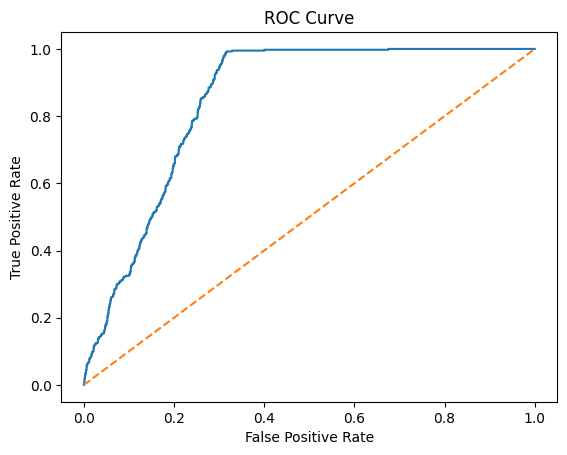

In [34]:
# Draw ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [41]:
# Lag 1 year

# Sort
df_model = df_model.sort_values(['cik', 'year'])

# Lag
lag_vars = [
    'rating_num',
    'current_ratio',
    'debt_equity',
    'roa',
    'asset_turnover'
]

for v in lag_vars:
    df_model[f'{v}_lag_1'] = (
        df_model
        .groupby('cik')[v]
        .shift(1)
    )

df_model_lag = df_model.dropna(
    subset=[f'{v}_lag_1' for v in lag_vars]
)

# df_model.shape
df_model_lag.shape

(1979, 34)

In [42]:
# Set variables and model
X_lag = df_model_lag[[f'{v}_lag_1' for v in lag_vars]]
X_lag = sm.add_constant(X_lag)

y = df_model_lag['default_event']

logit_lag = sm.Logit(y, X_lag).fit()
print(logit_lag.summary())

Optimization terminated successfully.
         Current function value: 0.145244
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          default_event   No. Observations:                 1979
Model:                          Logit   Df Residuals:                     1973
Method:                           MLE   Df Model:                            5
Date:                Sat, 20 Dec 2025   Pseudo R-squ.:                0.006549
Time:                        12:03:50   Log-Likelihood:                -287.44
converged:                       True   LL-Null:                       -289.33
Covariance Type:            nonrobust   LLR p-value:                    0.5801
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.8467      0.360     -7.906      0.000      -3.552      -2.141